<a href="https://colab.research.google.com/github/Jaya-323/Python_AI_ML_practice/blob/main/Practice10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Computer vision and cnn

In [ ]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import numpy as py
import matplotlib.pyplot as plt
print("Libraries imported successfully")

Libraries imported successfully


Loading mnist dataset

In [ ]:
mnist=keras.datasets.mnist
(X_train,Y_train),(X_test,Y_test)=mnist.load_data()
print(X_train.shape)

(60000, 28, 28)


Visualize image

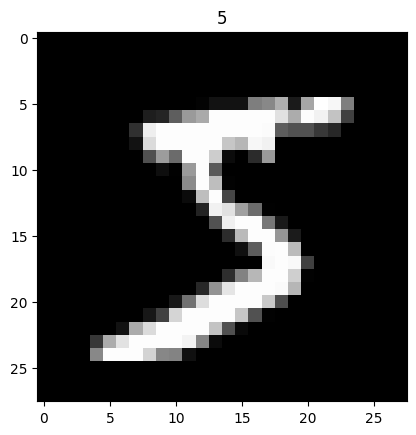

In [ ]:
plt.imshow(X_train[0],cmap="gray")
plt.title(Y_train[0])
plt.show()

Normalize image

In [ ]:
X_train=X_train/255.0
X_test=X_test/255.0

Reshape image

In [ ]:
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)
print(X_train.shape)

(60000, 28, 28, 1)


CNN model creation

In [ ]:
model=keras.Sequential([
    keras.layers.Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)),
    keras.layers.MaxPool2D(2,2),
    keras.layers.Flatten(),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(10,activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Train model

In [ ]:
history=model.fit(
    X_train,Y_train,
    epochs=10,
    validation_data=(X_test,Y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.9492 - loss: 0.1727 - val_accuracy: 0.9779 - val_loss: 0.0707
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9816 - loss: 0.0612 - val_accuracy: 0.9830 - val_loss: 0.0486
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9873 - loss: 0.0411 - val_accuracy: 0.9831 - val_loss: 0.0501
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.9831 - val_loss: 0.0479
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9936 - loss: 0.0200 - val_accuracy: 0.9844 - val_loss: 0.0484
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9954 - loss: 0.0153 - val_accuracy: 0.9873 - val_loss: 0.0422
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9963 - loss: 0.0115 - val_accuracy: 0.9854 - val_loss: 0.0473
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9973 -

Evaluate model

In [ ]:
loss, accuracy=model.evaluate( X_test,Y_test)
print("Loss",loss)
print("Accuracy",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9873 - loss: 0.0518
Loss 0.051847077906131744
Accuracy 0.9872999787330627


Prediction

In [ ]:
prediction=model.predict(X_test)
print(prediction[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
[9.2788699e-14 5.0528565e-10 1.1307606e-11 2.3371893e-08 5.6838967e-14
 9.1654436e-12 2.0867192e-20 9.9999994e-01 6.0693690e-12 3.3482315e-09]


digit prediction

In [ ]:
prediction_digit=py.argmax(prediction[9])
print(prediction_digit)

9
